In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
dfins = pd.read_csv(r"/content/insurance (2).csv")
dfins

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [2]:
dfins.shape

(1338, 7)

**feature selection**

In [3]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


lookout for the nans

In [4]:
dfins.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
dfins.isna().sum().sum()

np.int64(0)

Error detection

In [6]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: >

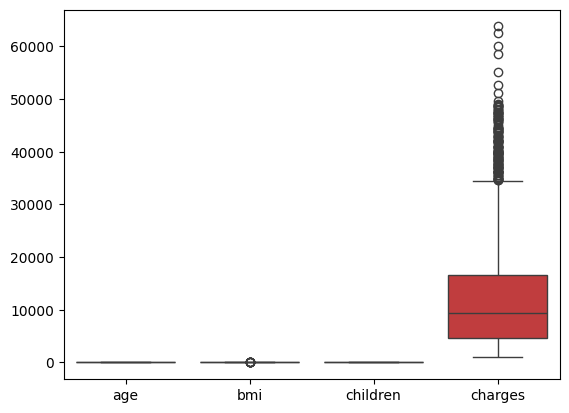

In [7]:
sns.boxplot(dfins)

<Axes: ylabel='bmi'>

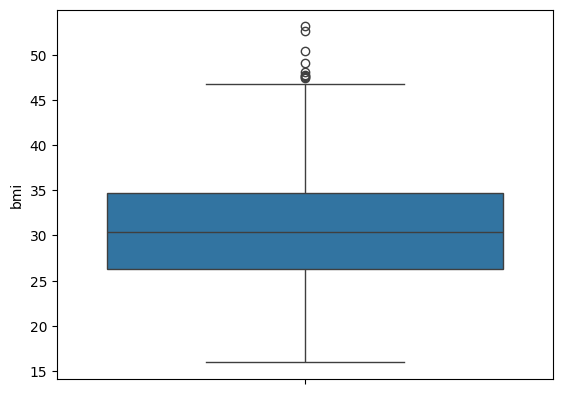

In [8]:
sns.boxplot(dfins['bmi'])

applying iqr on bmi column

In [9]:
dfins["bmi"]

,bmi
0,27.900
1,33.770
2,33.000
3,22.705
4,28.880
...,...
1333,30.970
1334,31.920
1335,36.850
1336,25.800


In [10]:
dfins["bmi"].describe()

,bmi
count,1338.000000
mean,30.663397
std,6.098187
min,15.960000
25%,26.296250
50%,30.400000
75%,34.693750
max,53.130000


In [11]:
q1 = dfins["bmi"].quantile(0.25)
q1

np.float64(26.29625)

In [12]:
q3 = dfins["bmi"].quantile(0.75)
q3

np.float64(34.69375)

In [13]:
iqr = q3-q1
iqr

np.float64(8.3975)

In [14]:
lower = q1 - (1.5 * iqr)
lower

np.float64(13.7)

In [15]:
upper = q3 + (1.5 * iqr)
upper

np.float64(47.290000000000006)

In [16]:
dfins[dfins["bmi"] < lower]

,age,sex,bmi,children,smoker,region,charges


In [17]:
dfins[dfins["bmi"] > upper]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


In [18]:
(dfins["bmi"] < lower) | (dfins["bmi"] > upper)

,bmi
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


In [19]:
dfins[(dfins["bmi"] < lower) | (dfins["bmi"] > upper)]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


Trimming

In [20]:
dfins[(dfins["bmi"] < lower) | (dfins["bmi"] > upper)].index

Index([116, 286, 401, 543, 847, 860, 1047, 1088, 1317], dtype='int64')

caping

In [21]:
dfins["bmi"]

,bmi
0,27.900
1,33.770
2,33.000
3,22.705
4,28.880
...,...
1333,30.970
1334,31.920
1335,36.850
1336,25.800


In [22]:
dfins["bmi"].map(lambda x :lower if x < lower else upper if x > upper else x)

,bmi
0,27.900
1,33.770
2,33.000
3,22.705
4,28.880
...,...
1333,30.970
1334,31.920
1335,36.850
1336,25.800


In [23]:
dfins["bmi"] = dfins["bmi"].map(lambda x :lower if x < lower else upper if x > upper else x)

In [24]:
dfins[(dfins["bmi"] < lower) | (dfins["bmi"] > upper)]

,age,sex,bmi,children,smoker,region,charges


<Axes: ylabel='bmi'>

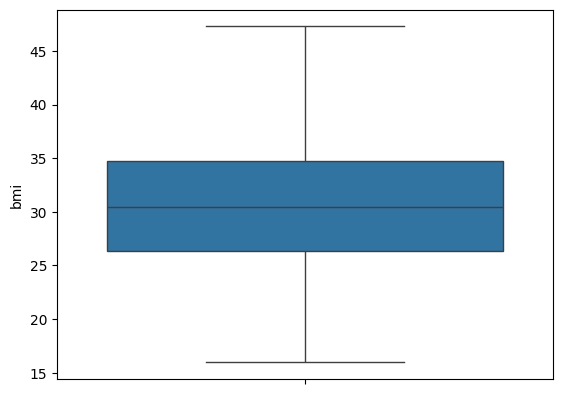

In [25]:
sns.boxplot(dfins["bmi"])

<Axes: >

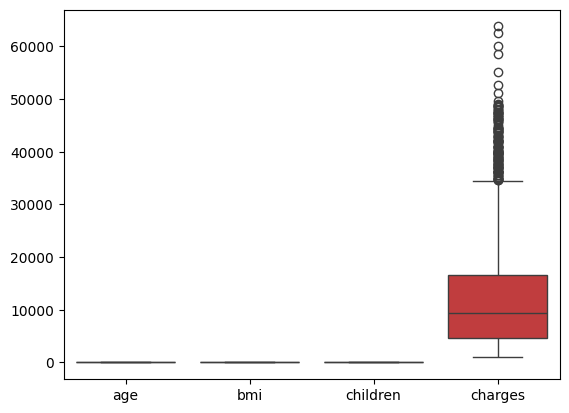

In [26]:
sns.boxplot(dfins)

Encoding

In [27]:
dfins.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [28]:
dfins["sex"]

,sex
0,female
1,male
2,male
3,male
4,male
...,...
1333,male
1334,female
1335,female
1336,female


In [29]:
dfins["sex"].unique()

array(['female', 'male'], dtype=object)

In [30]:
dfins['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [31]:
dfins["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
ohe = OneHotEncoder()

In [34]:
ohe

OneHotEncoder()

In [35]:
ohe.fit(dfins[["sex"]])

OneHotEncoder()

In [36]:
ohe.transform(dfins[["sex"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1338 stored elements and shape (1338, 2)>

In [ ]:
arr = ohe.transform(dfins[["sex"]]).toarray()  #from sparse matrix to array


In [48]:
arr

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [39]:
ohe.categories_

[array(['female', 'male'], dtype=object)]

In [40]:
pd.DataFrame(arr, dtype = int, columns = ["sex_female", "sex_male"]) # this will change float into int by using dtype

,sex_female,sex_male
0,1,0
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
1333,0,1
1334,1,0
1335,1,0
1336,1,0


In [41]:
dfnew = pd.DataFrame(arr, dtype = int, columns = ["sex_female", "sex_male"]) # this will change float into int by using dtype


In [42]:
dfins = pd.concat([dfins, dfnew], axis=1)
dfins.head()

,age,sex,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [43]:
dfins.head()

,age,sex,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [44]:
dfins.drop("sex", axis = 1)

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,1,0
1,18,33.770,1,no,southeast,1725.55230,0,1
2,28,33.000,3,no,southeast,4449.46200,0,1
3,33,22.705,0,no,northwest,21984.47061,0,1
4,32,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,no,northwest,10600.54830,0,1
1334,18,31.920,0,no,northeast,2205.98080,1,0
1335,18,36.850,0,no,southeast,1629.83350,1,0
1336,21,25.800,0,no,southwest,2007.94500,1,0


In [45]:
dfins.drop("sex", axis = 1, inplace = True)


In [46]:
dfins

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,1,0
1,18,33.770,1,no,southeast,1725.55230,0,1
2,28,33.000,3,no,southeast,4449.46200,0,1
3,33,22.705,0,no,northwest,21984.47061,0,1
4,32,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,no,northwest,10600.54830,0,1
1334,18,31.920,0,no,northeast,2205.98080,1,0
1335,18,36.850,0,no,southeast,1629.83350,1,0
1336,21,25.800,0,no,southwest,2007.94500,1,0


region column

In [49]:
dfins["region"]

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
1333,northwest
1334,northeast
1335,southeast
1336,southwest


In [50]:
dfins["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [61]:
from sklearn.preprocessing import OneHotEncoder
ohe1 = OneHotEncoder(drop = "first")
ohe1

OneHotEncoder(drop='first')

In [62]:
ohe1.fit(dfins[["region"]])

OneHotEncoder(drop='first')

In [63]:
ohe1.transform(dfins[["region"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1014 stored elements and shape (1338, 3)>

In [64]:
arr_region = ohe1.transform(dfins[["region"]]).toarray()
arr_region

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [65]:
ohe1.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [71]:
df_region = pd.DataFrame(arr_region, dtype = int, columns = ['region_northwest', 'region_southeast', 'region_southwest'])
df_region

,region_northwest,region_southeast,region_southwest
0,0,0,1
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
1333,1,0,0
1334,0,0,0
1335,0,1,0
1336,0,0,1


In [77]:
dfins.head()

,age,bmi,children,smoker,charges,sex_female,sex_male,age,bmi,children,...,age,bmi,children,smoker,charges,sex_female,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,yes,16884.92400,1,0,19,27.900,0,...,19,27.900,0,yes,16884.92400,1,0,0,0,1
1,18,33.770,1,no,1725.55230,0,1,18,33.770,1,...,18,33.770,1,no,1725.55230,0,1,0,1,0
2,28,33.000,3,no,4449.46200,0,1,28,33.000,3,...,28,33.000,3,no,4449.46200,0,1,0,1,0
3,33,22.705,0,no,21984.47061,0,1,33,22.705,0,...,33,22.705,0,no,21984.47061,0,1,1,0,0
4,32,28.880,0,no,3866.85520,0,1,32,28.880,0,...,32,28.880,0,no,3866.85520,0,1,1,0,0


In [79]:
df_region.head()

,age,bmi,children,smoker,region,charges,sex_female,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,yes,southwest,16884.92400,1,0,0,0,1
1,18,33.770,1,no,southeast,1725.55230,0,1,0,1,0
2,28,33.000,3,no,southeast,4449.46200,0,1,0,1,0
3,33,22.705,0,no,northwest,21984.47061,0,1,1,0,0
4,32,28.880,0,no,northwest,3866.85520,0,1,1,0,0


In [110]:
dfins = pd.concat([ df_region], axis = 1)
dfins

,age,bmi,children,smoker,region,charges,sex_female,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.900,0,yes,southwest,16884.92400,1,0,0,0,1
1,18,33.770,1,no,southeast,1725.55230,0,1,0,1,0
2,28,33.000,3,no,southeast,4449.46200,0,1,0,1,0
3,33,22.705,0,no,northwest,21984.47061,0,1,1,0,0
4,32,28.880,0,no,northwest,3866.85520,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,no,northwest,10600.54830,0,1,1,0,0
1334,18,31.920,0,no,northeast,2205.98080,1,0,0,0,0
1335,18,36.850,0,no,southeast,1629.83350,1,0,0,1,0
1336,21,25.800,0,no,southwest,2007.94500,1,0,0,0,1
